In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from thermoift import MLPreprocessing

In [2]:
dfs = []

for i in range(100):
    path = f"../DATASET_A1/1682392_{i}/CSV/interfacial_results/feed_1_interfacial_results.csv"
    
    try:
        df = pd.read_csv(path)
        
        # Invalid Data Removal
        df = df[
            (df["vapor_density"] < 400) &
            (df["interfacial_thickness"] > 0)
        ]
        
        df["source_id"] = i
        dfs.append(df)
    except FileNotFoundError:
        print(f"Missing: {path}")

combined_df = pd.concat(dfs, ignore_index=True)
combined_df = combined_df.dropna(subset=["gamma"])
combined_df.to_csv("interfacial_results_dataset_A1.csv", index=False)

print(f"Combined {len(dfs)} datasets. Total rows: {len(combined_df)}")

Combined 100 datasets. Total rows: 19171


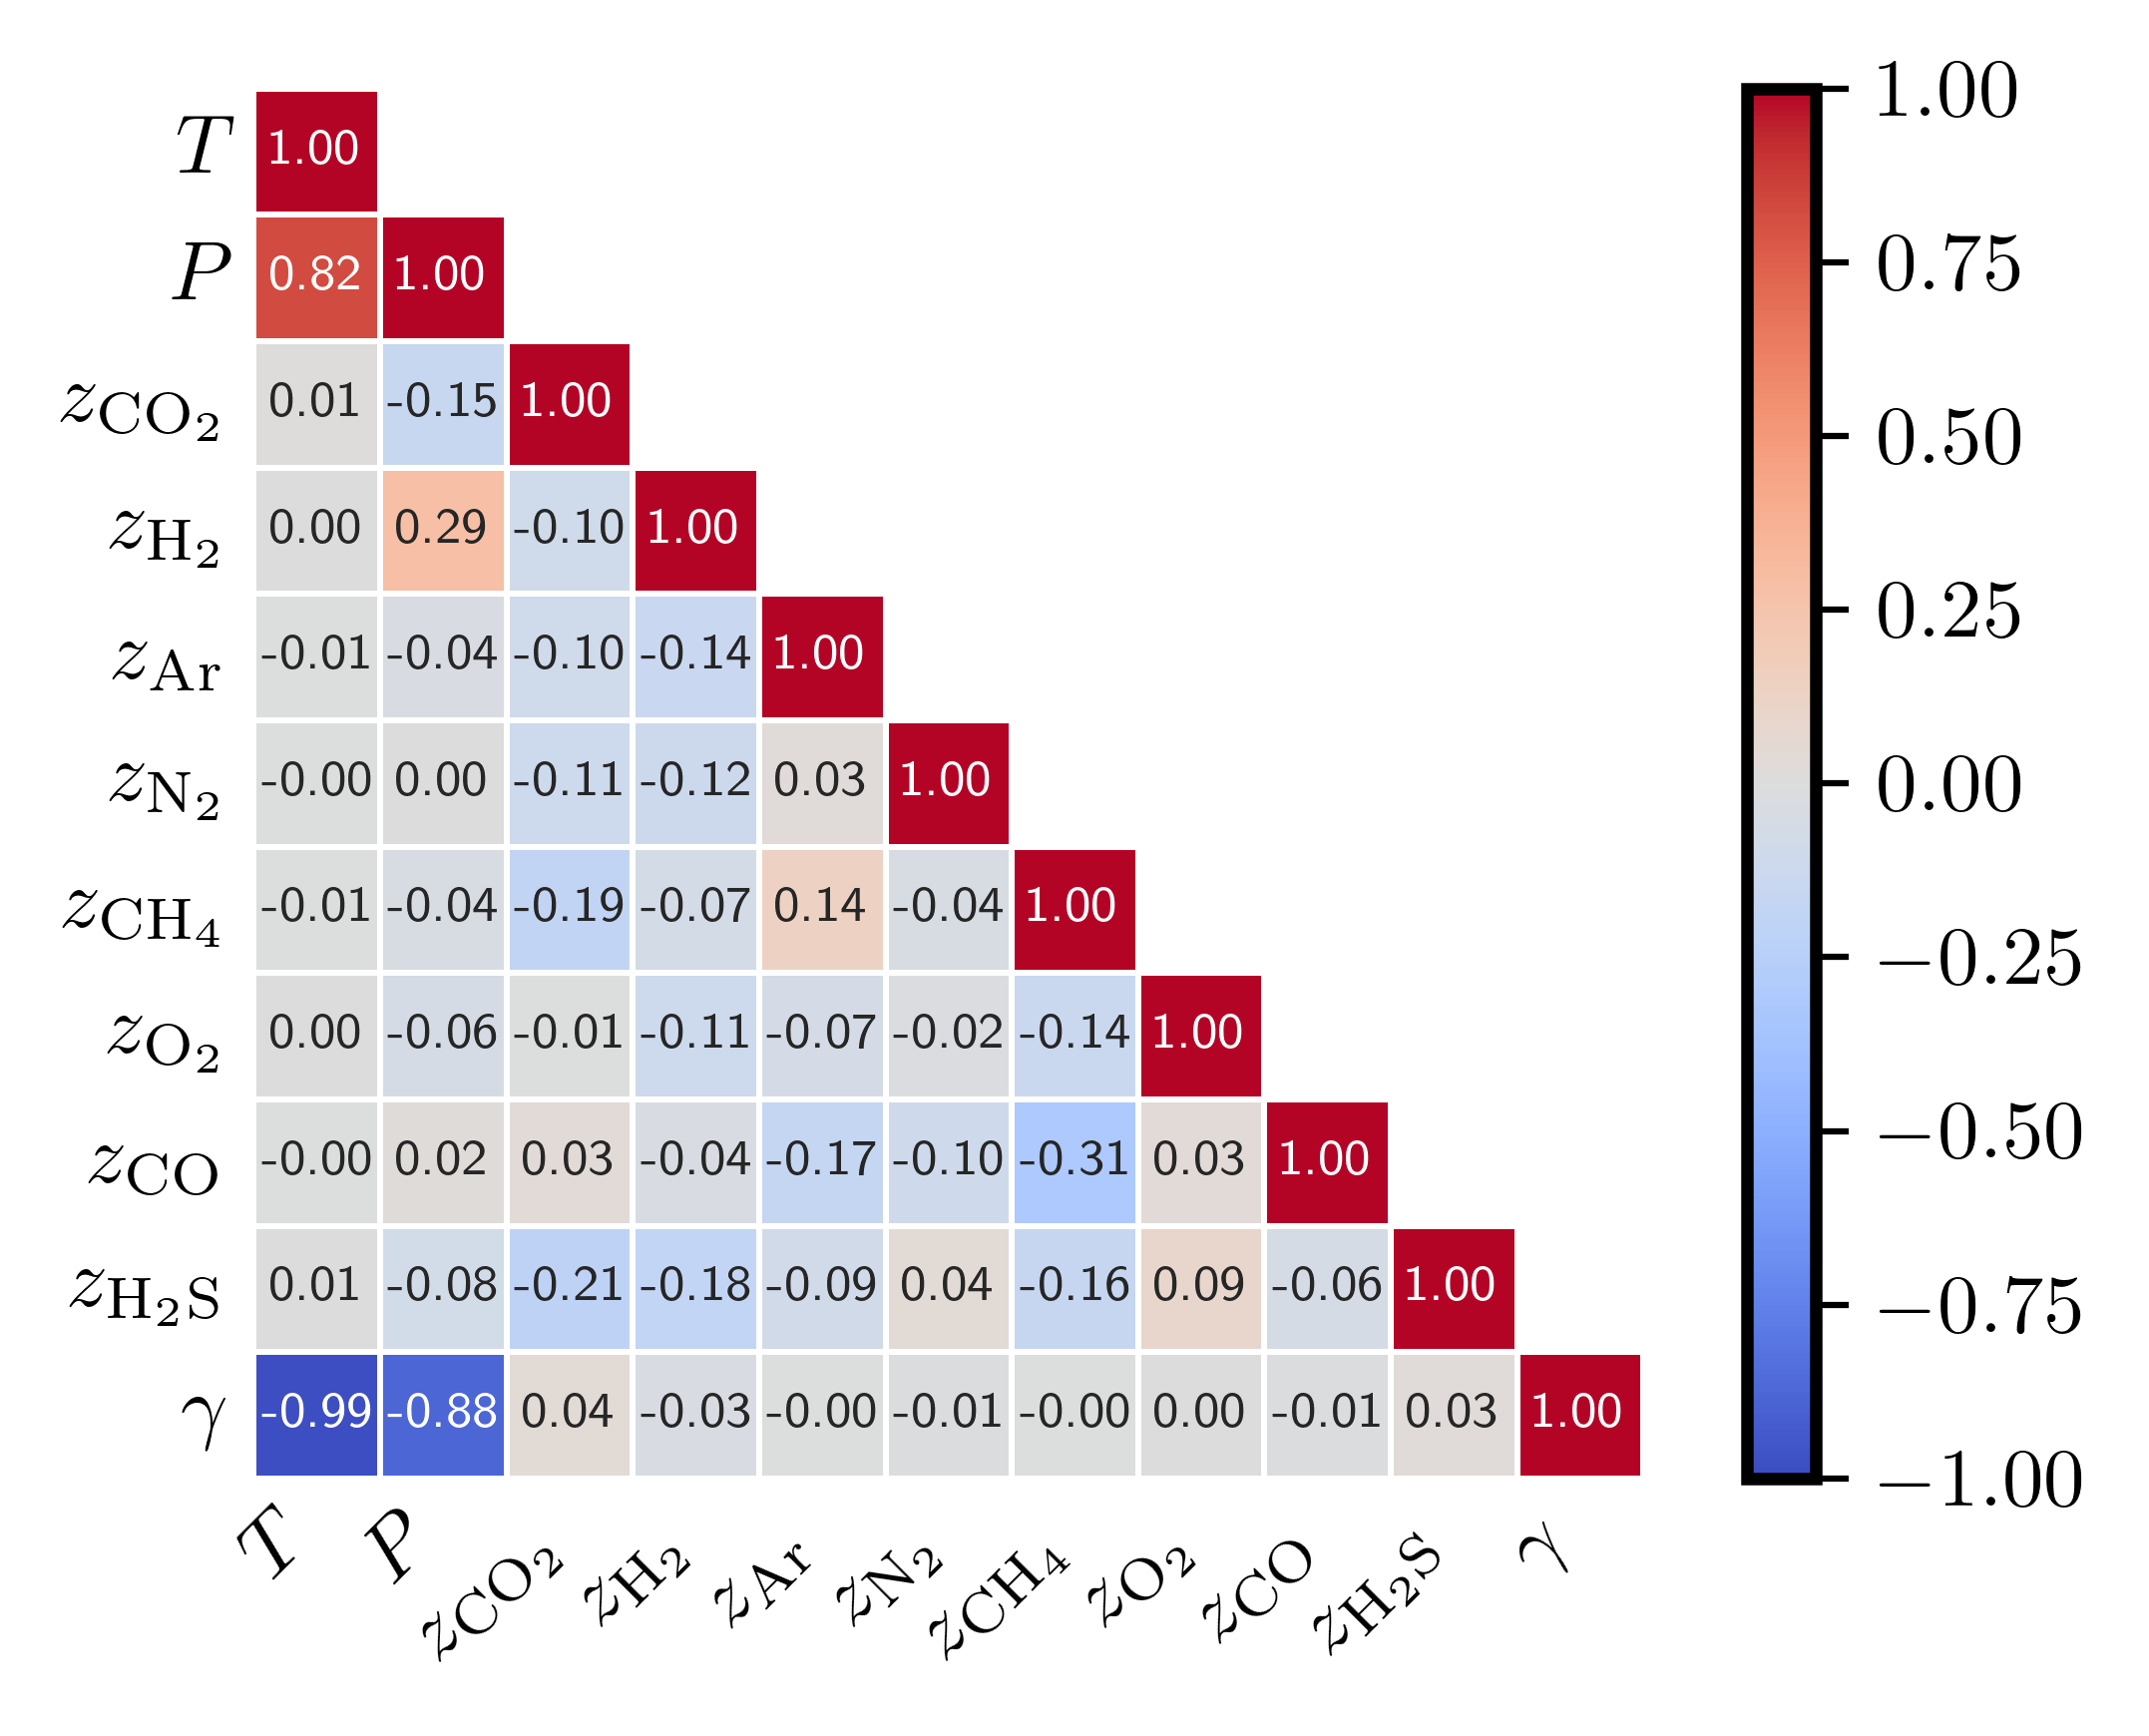

In [3]:
# Define target, components, and features
COMPONENTS = [
    "carbon dioxide",
    "hydrogen",
    "argon",
    "nitrogen",
    "methane",
    "oxygen",
    "carbon monoxide",
    "hydrogen sulfide"
]

target      = "gamma"
z_cols      = [f"z_{comp}" for comp in COMPONENTS if f"z_{comp}" in combined_df.columns]
features    = ["temperature", "pressure"] + z_cols
prep        = MLPreprocessing(df=combined_df, features=features, target=target)
fig, ax     = prep.plot_spearman_matrix(save_path="spearman_correlation_matrix")
plt.show()
# corr_df = prep.feature_target_correlations()
# corr_df

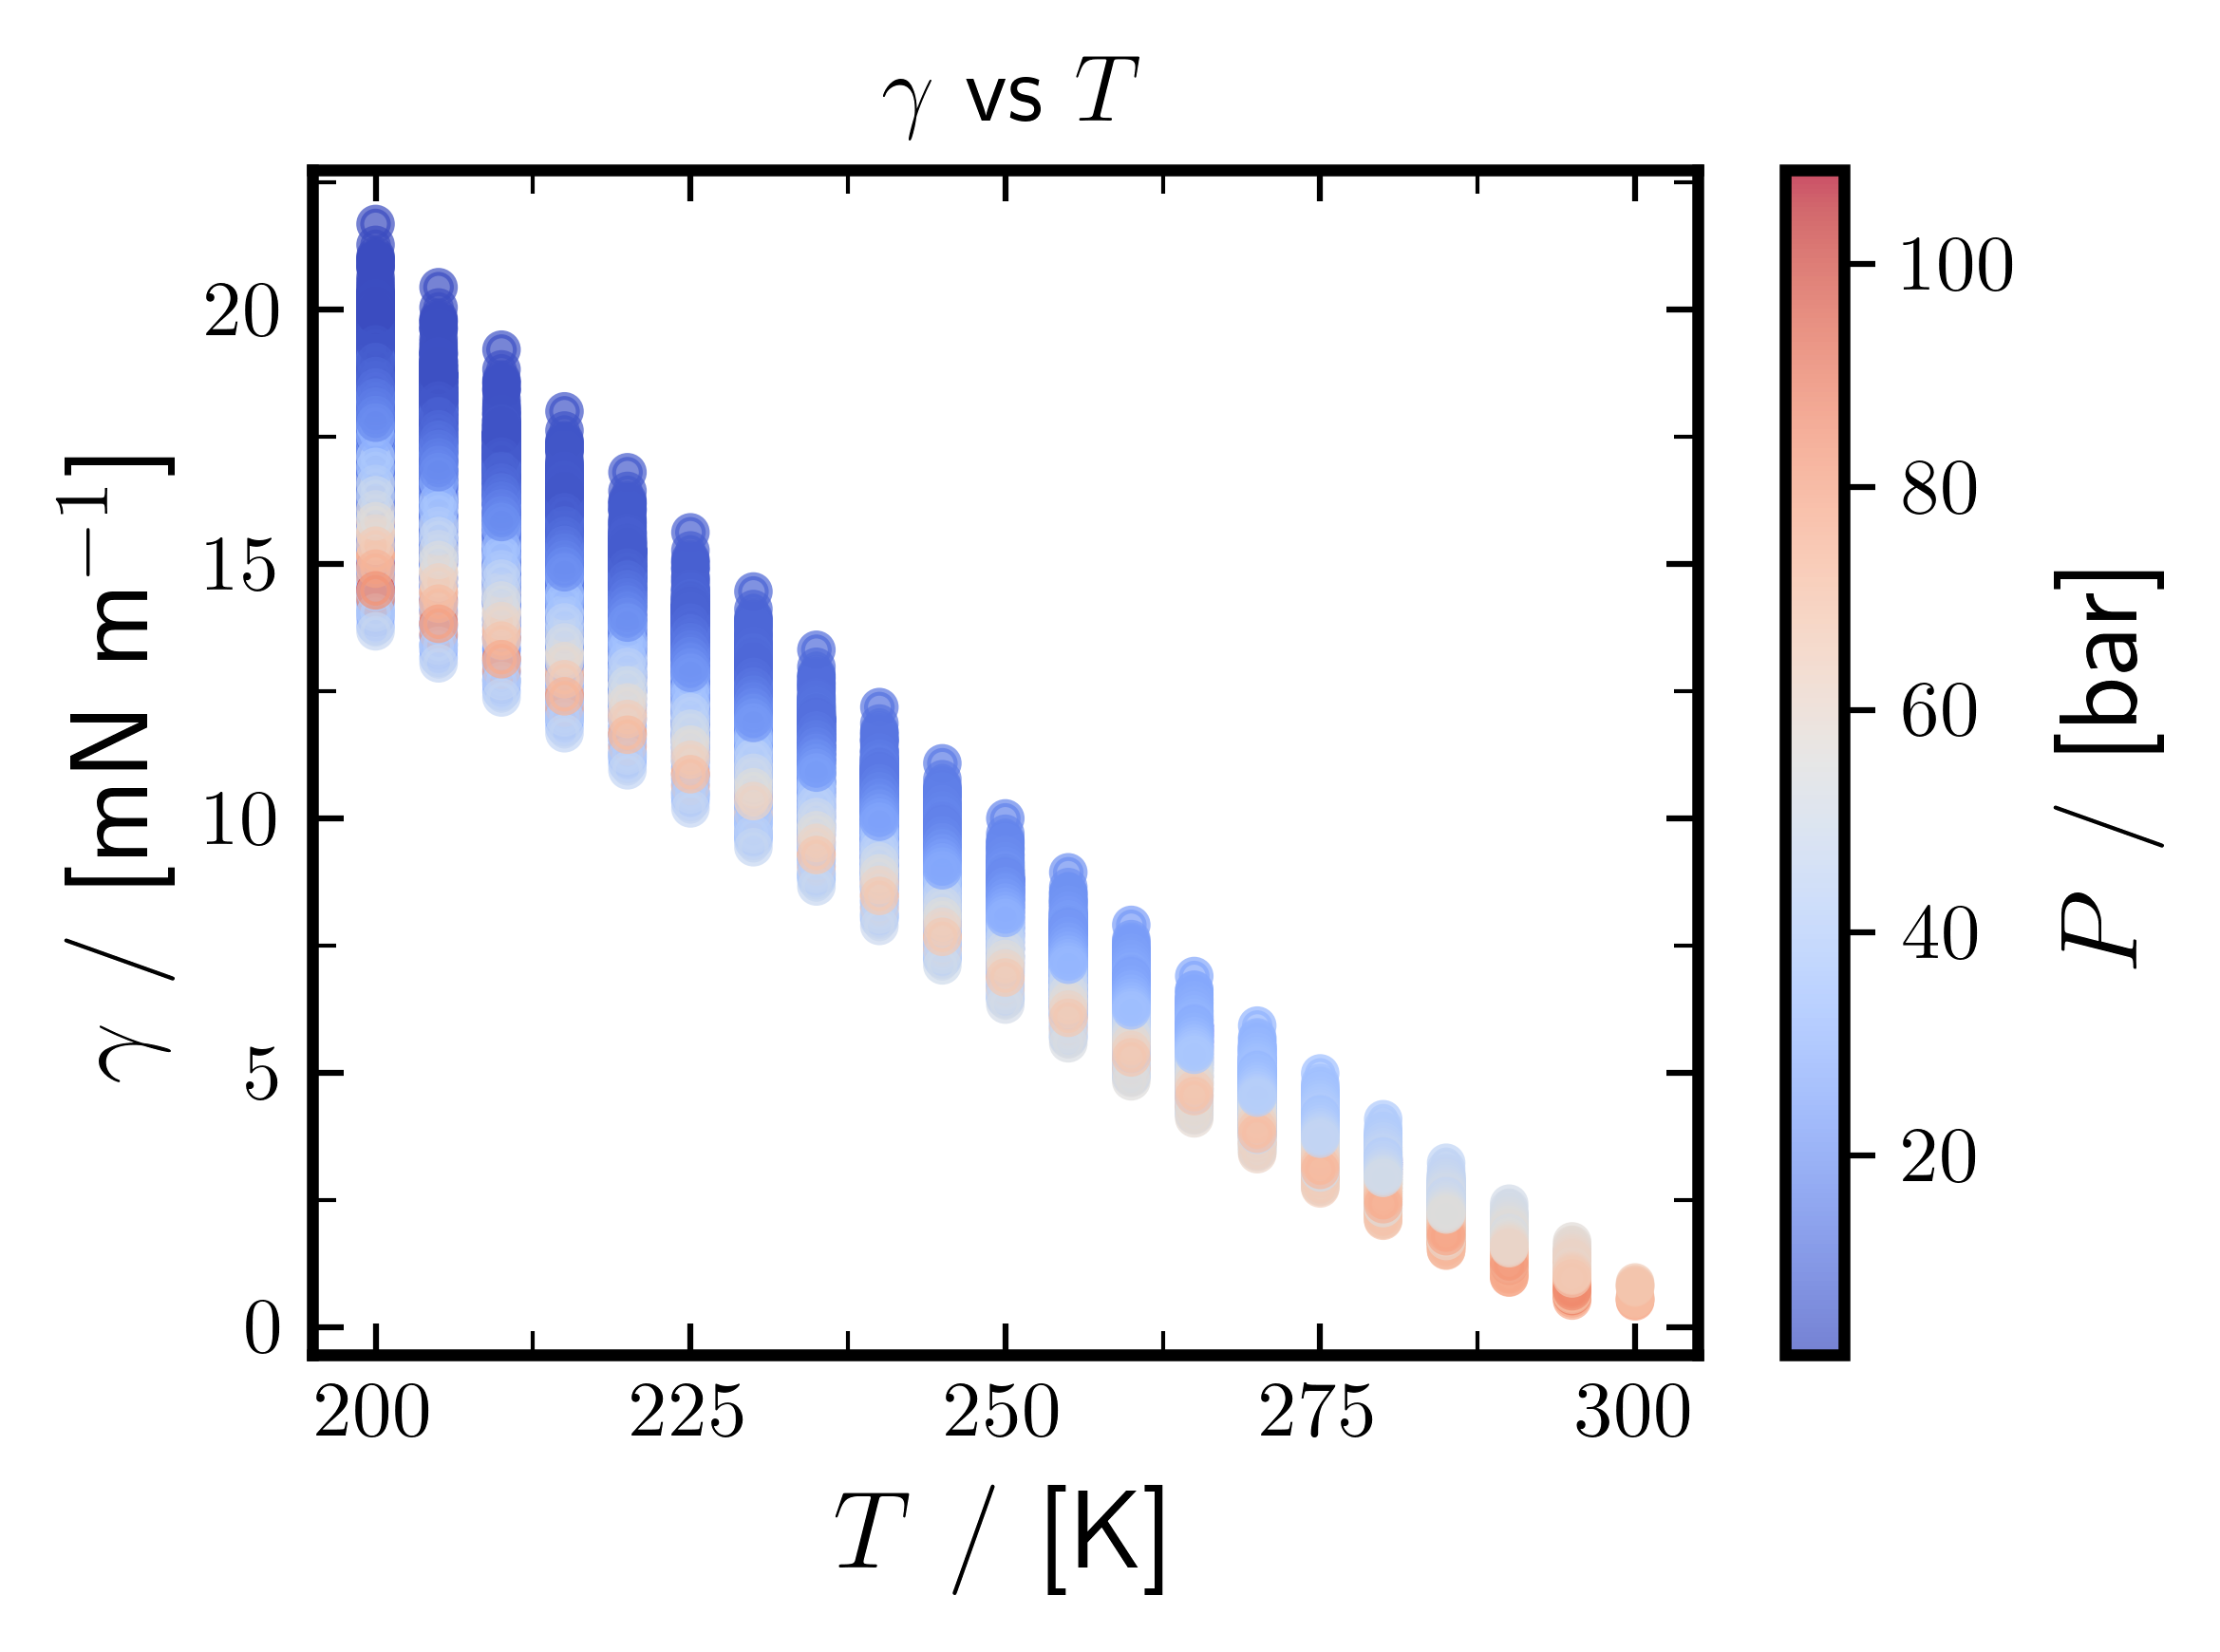

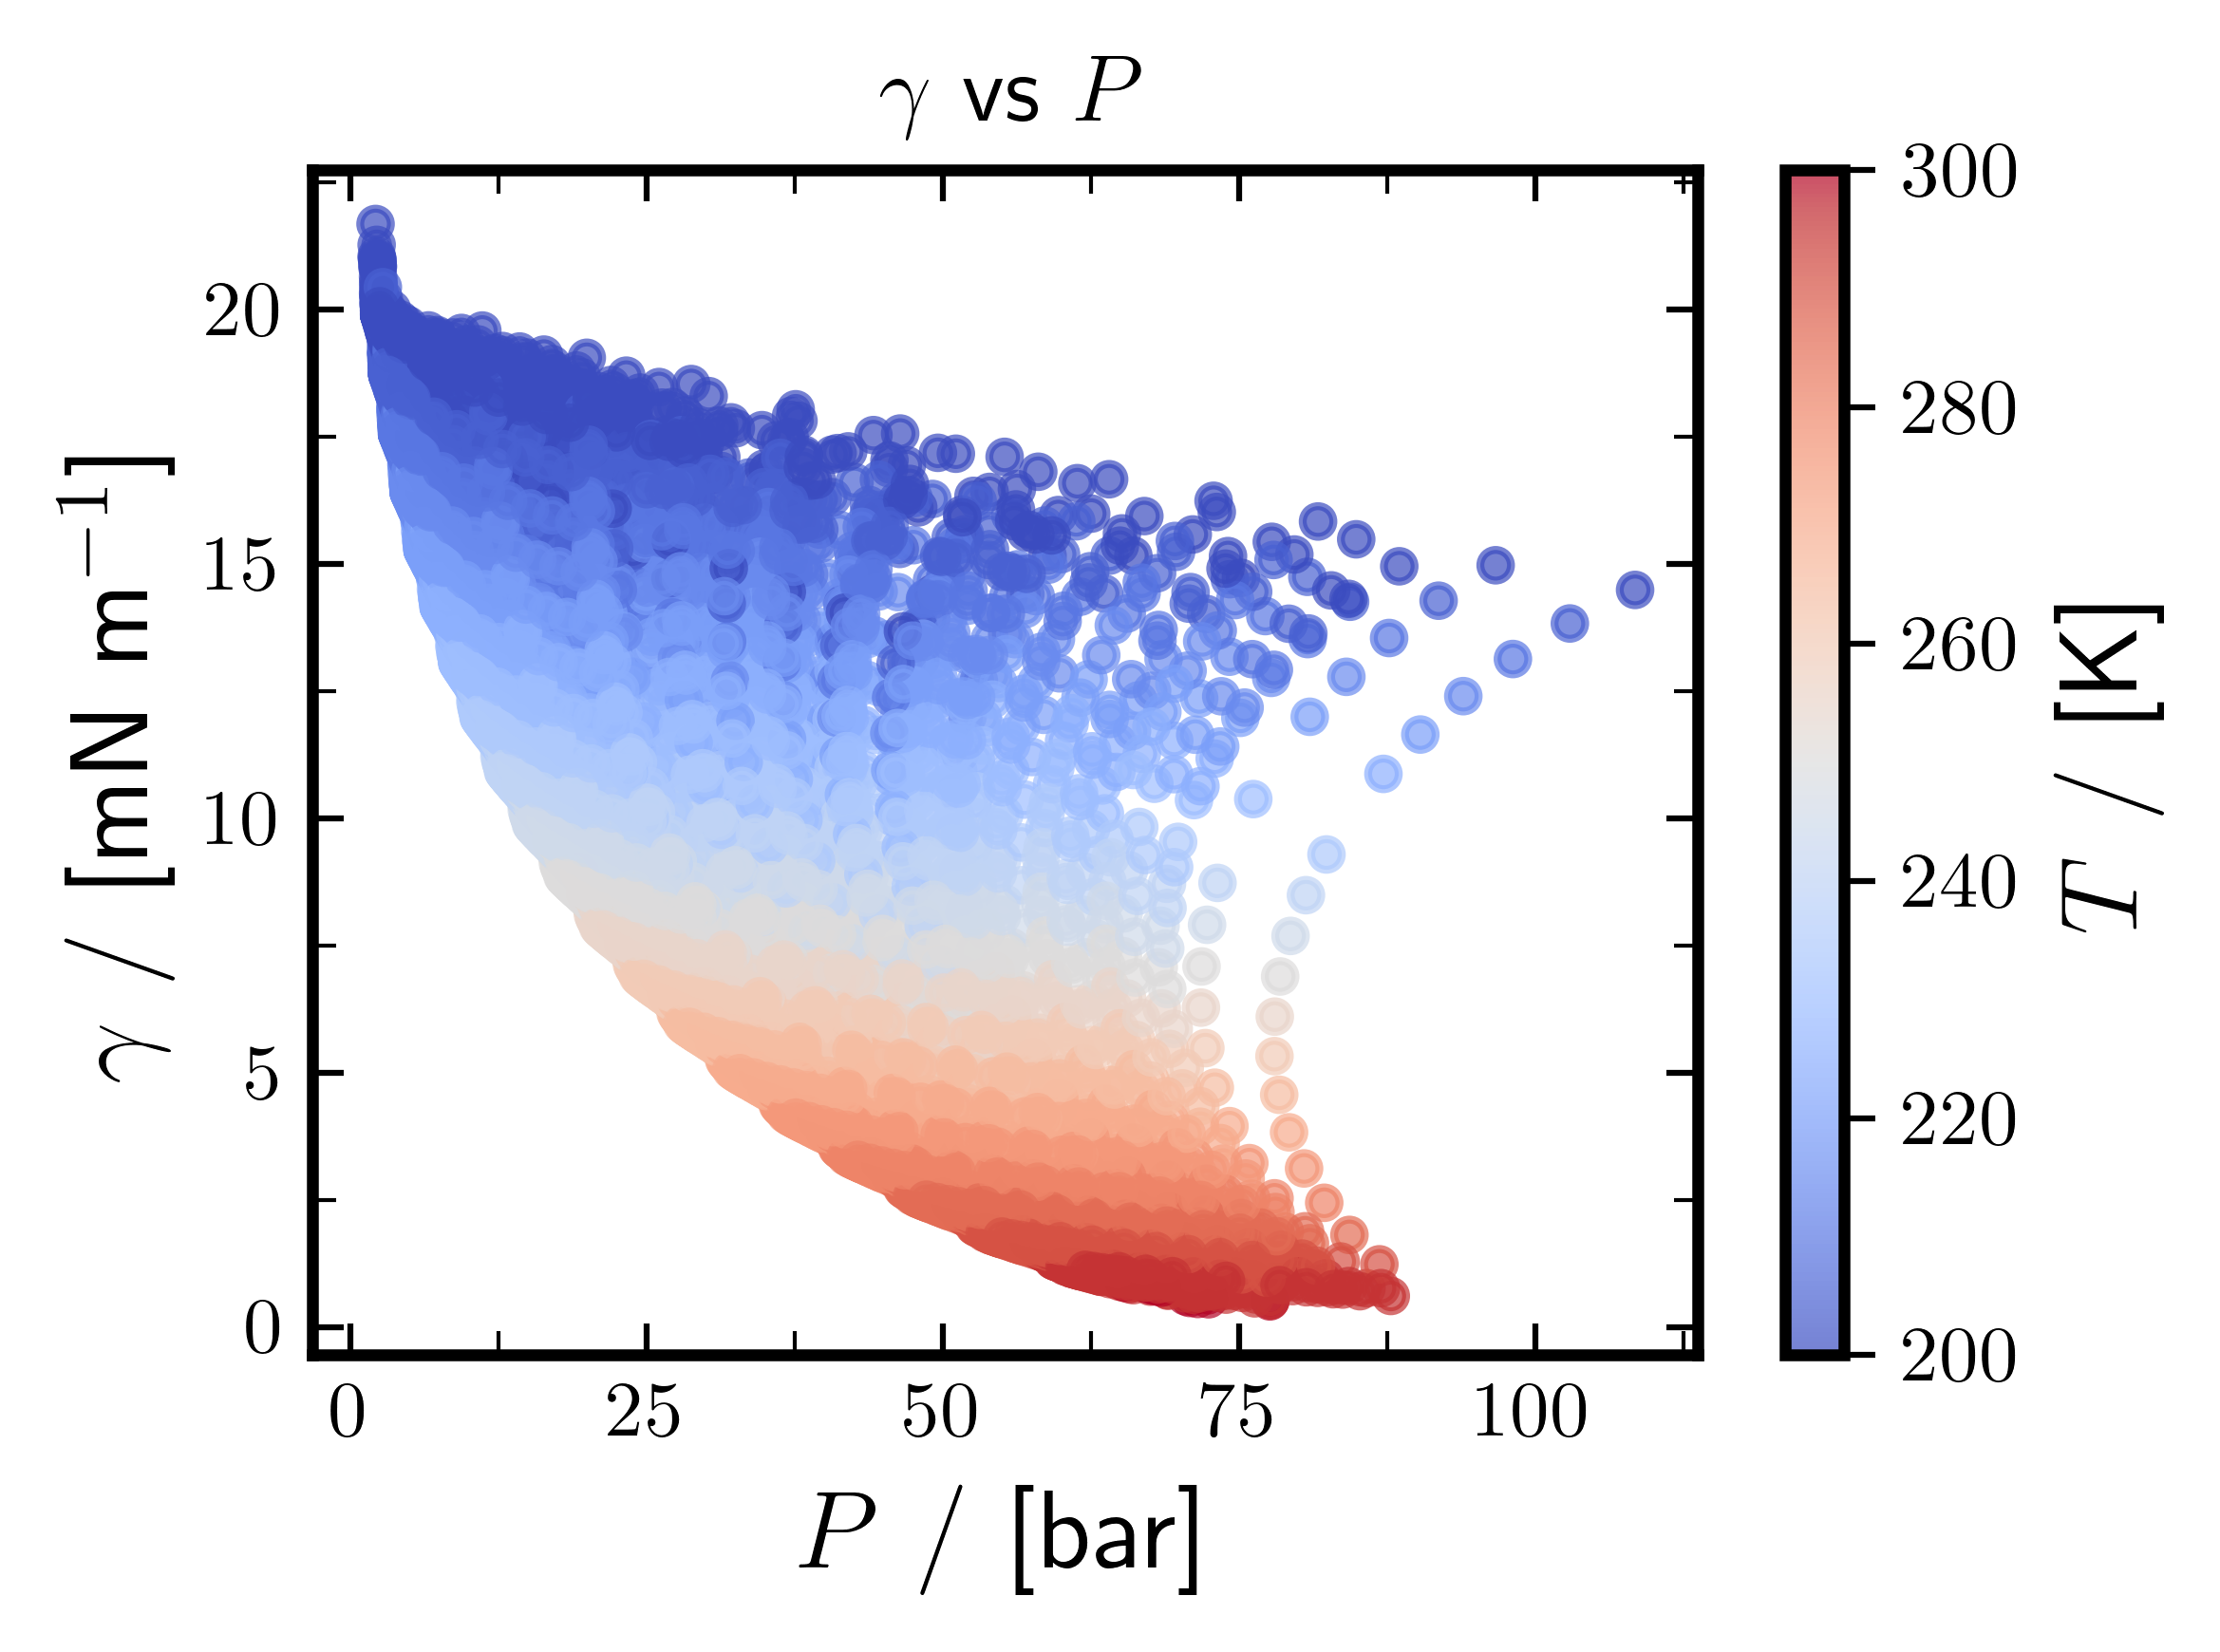

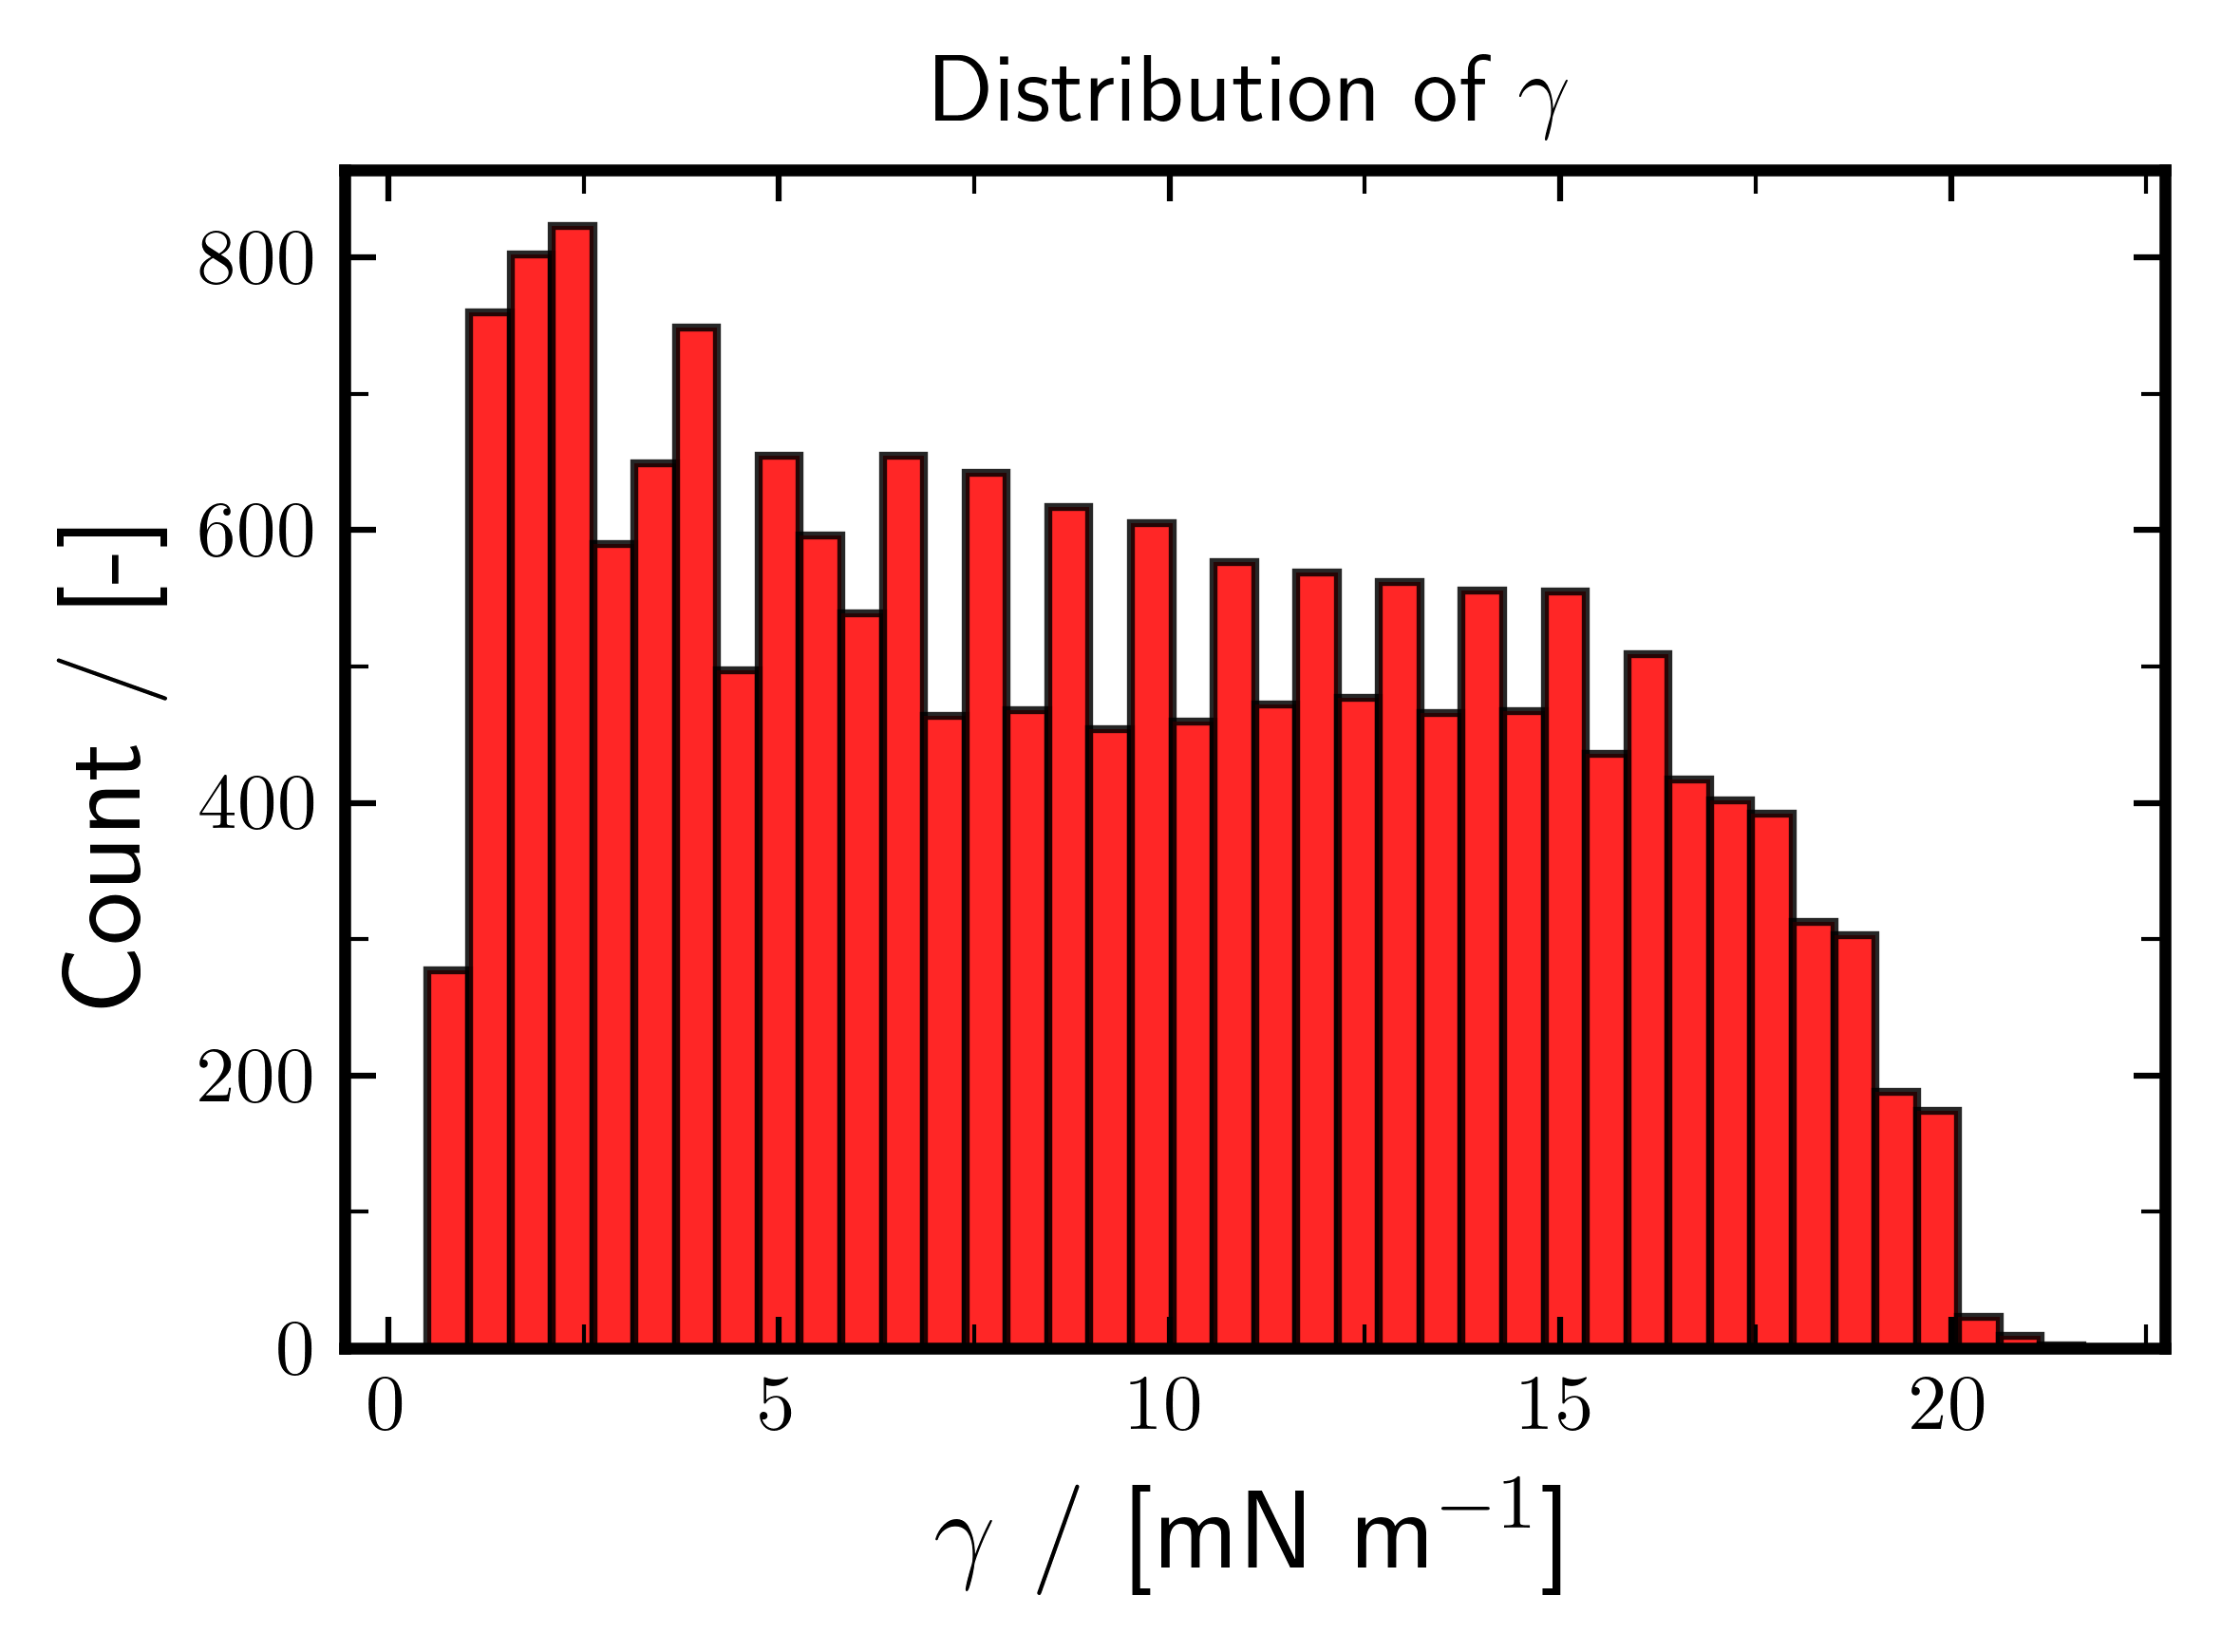

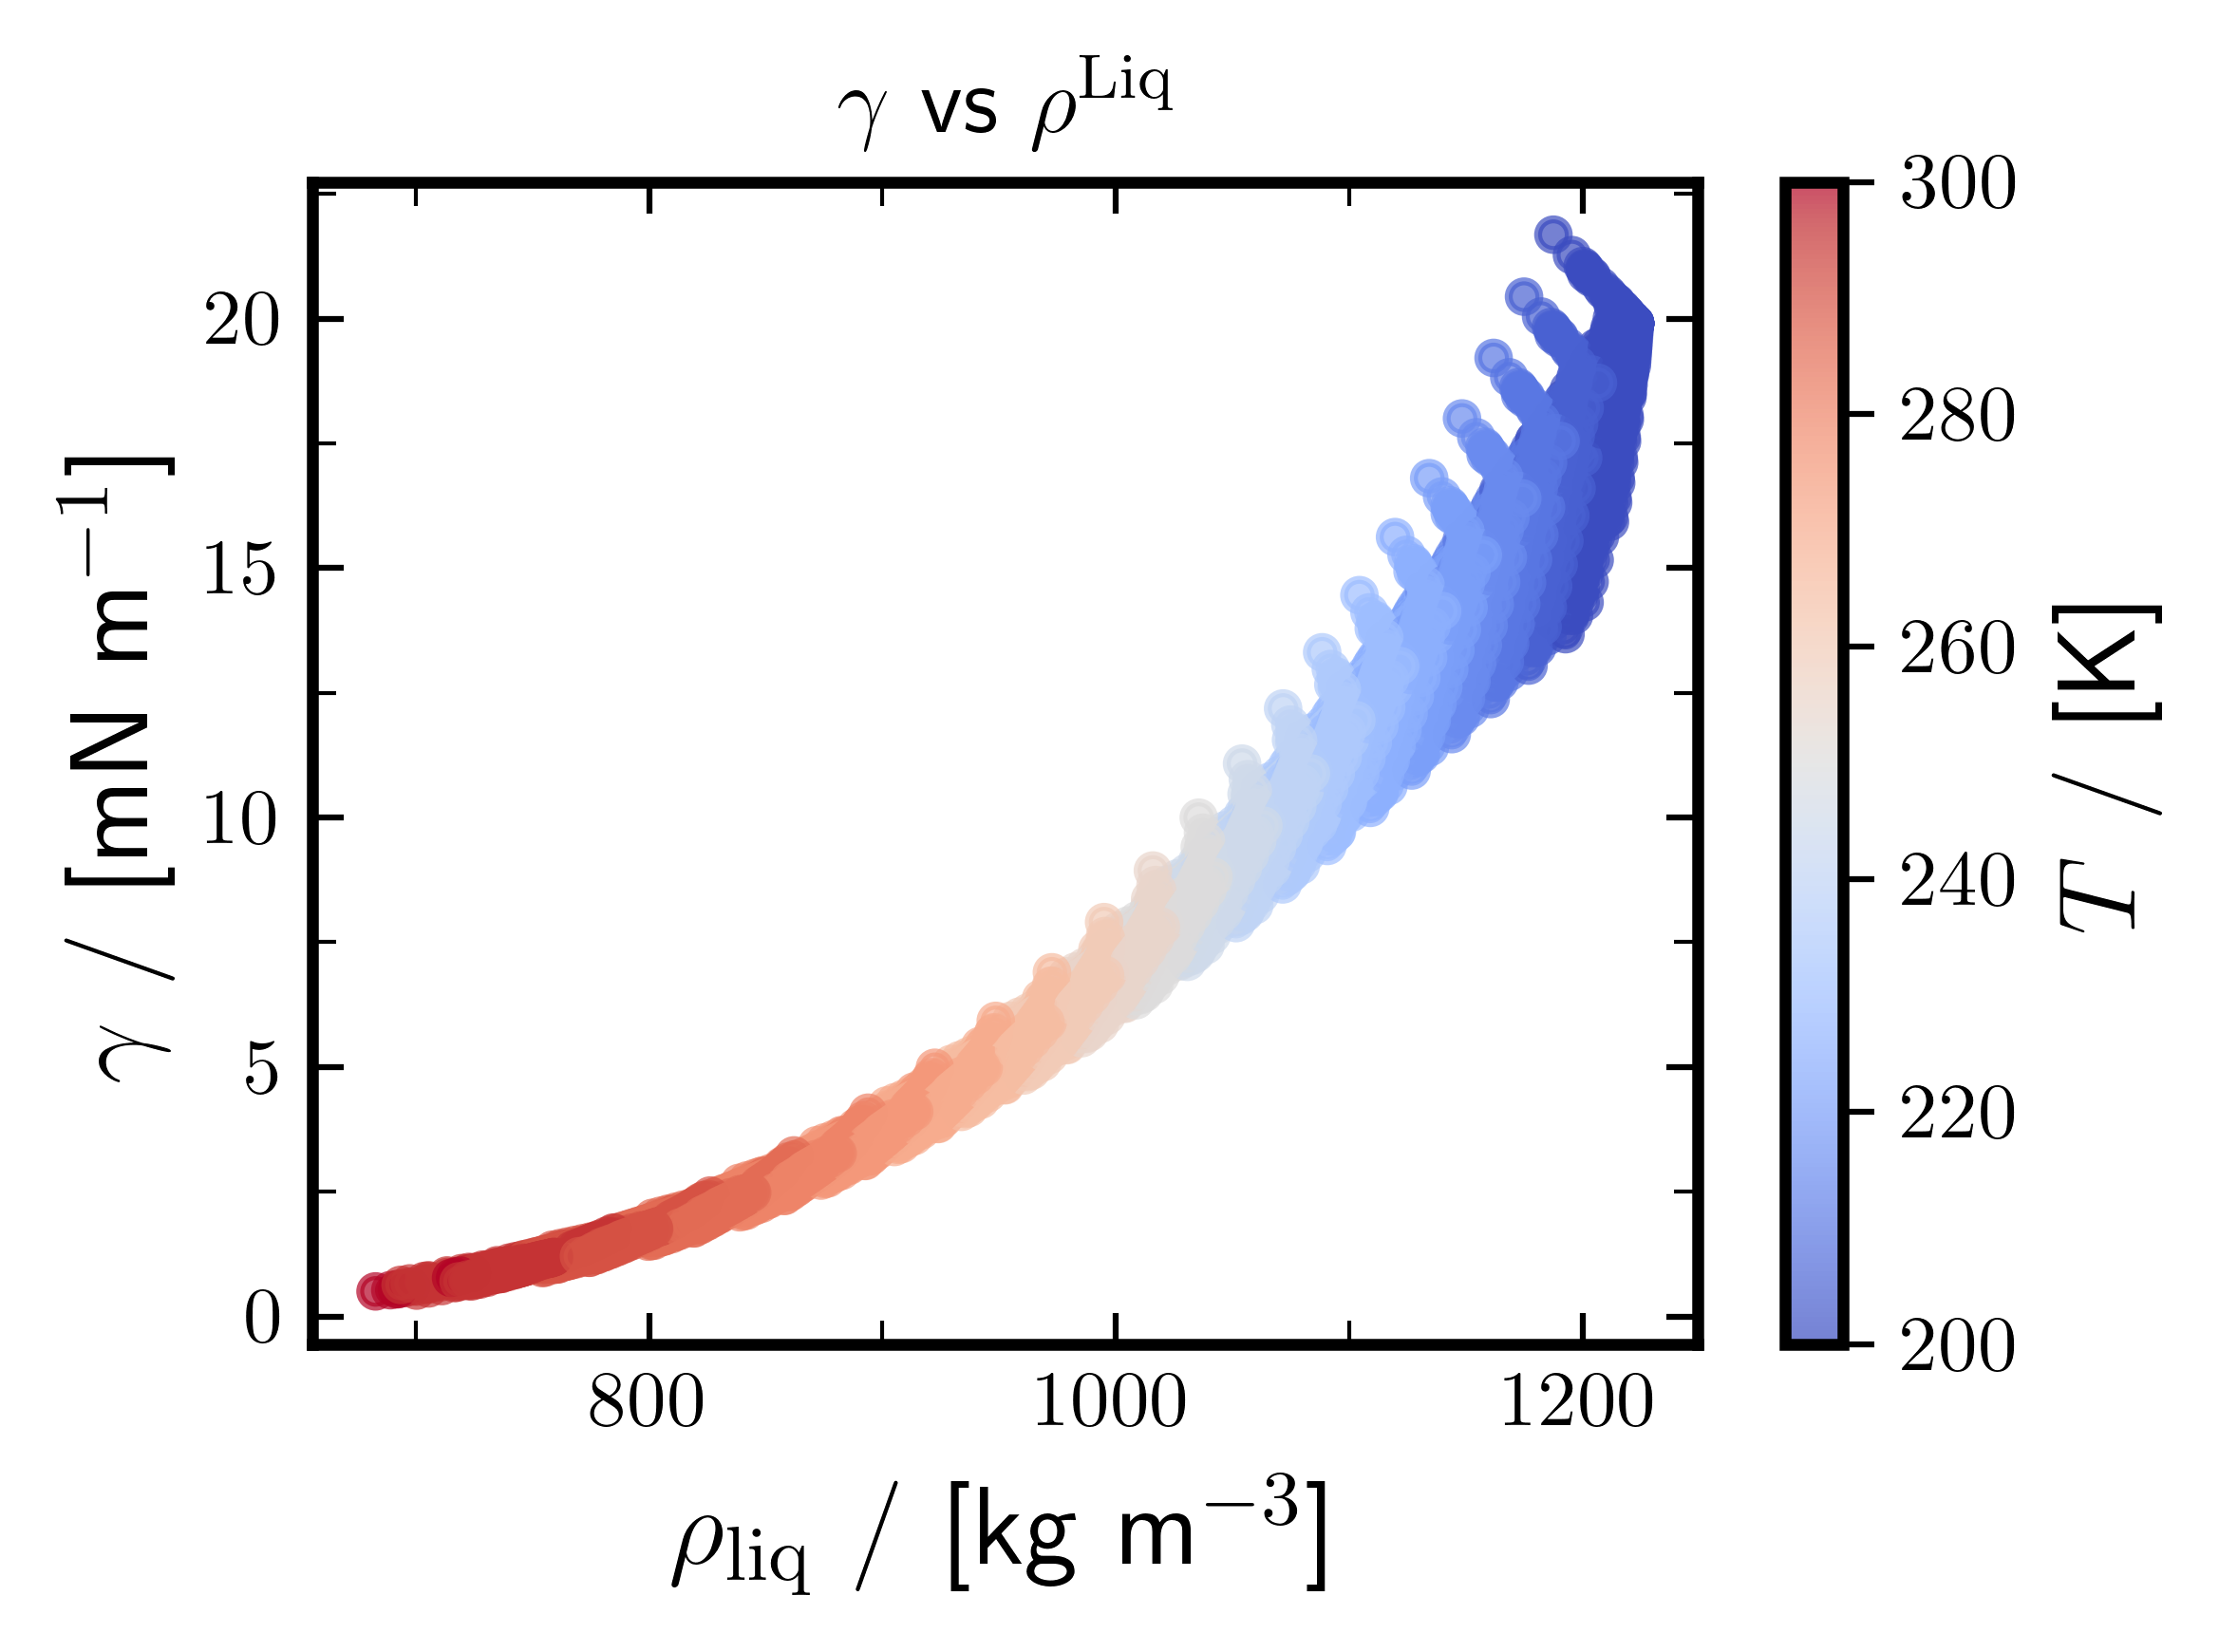

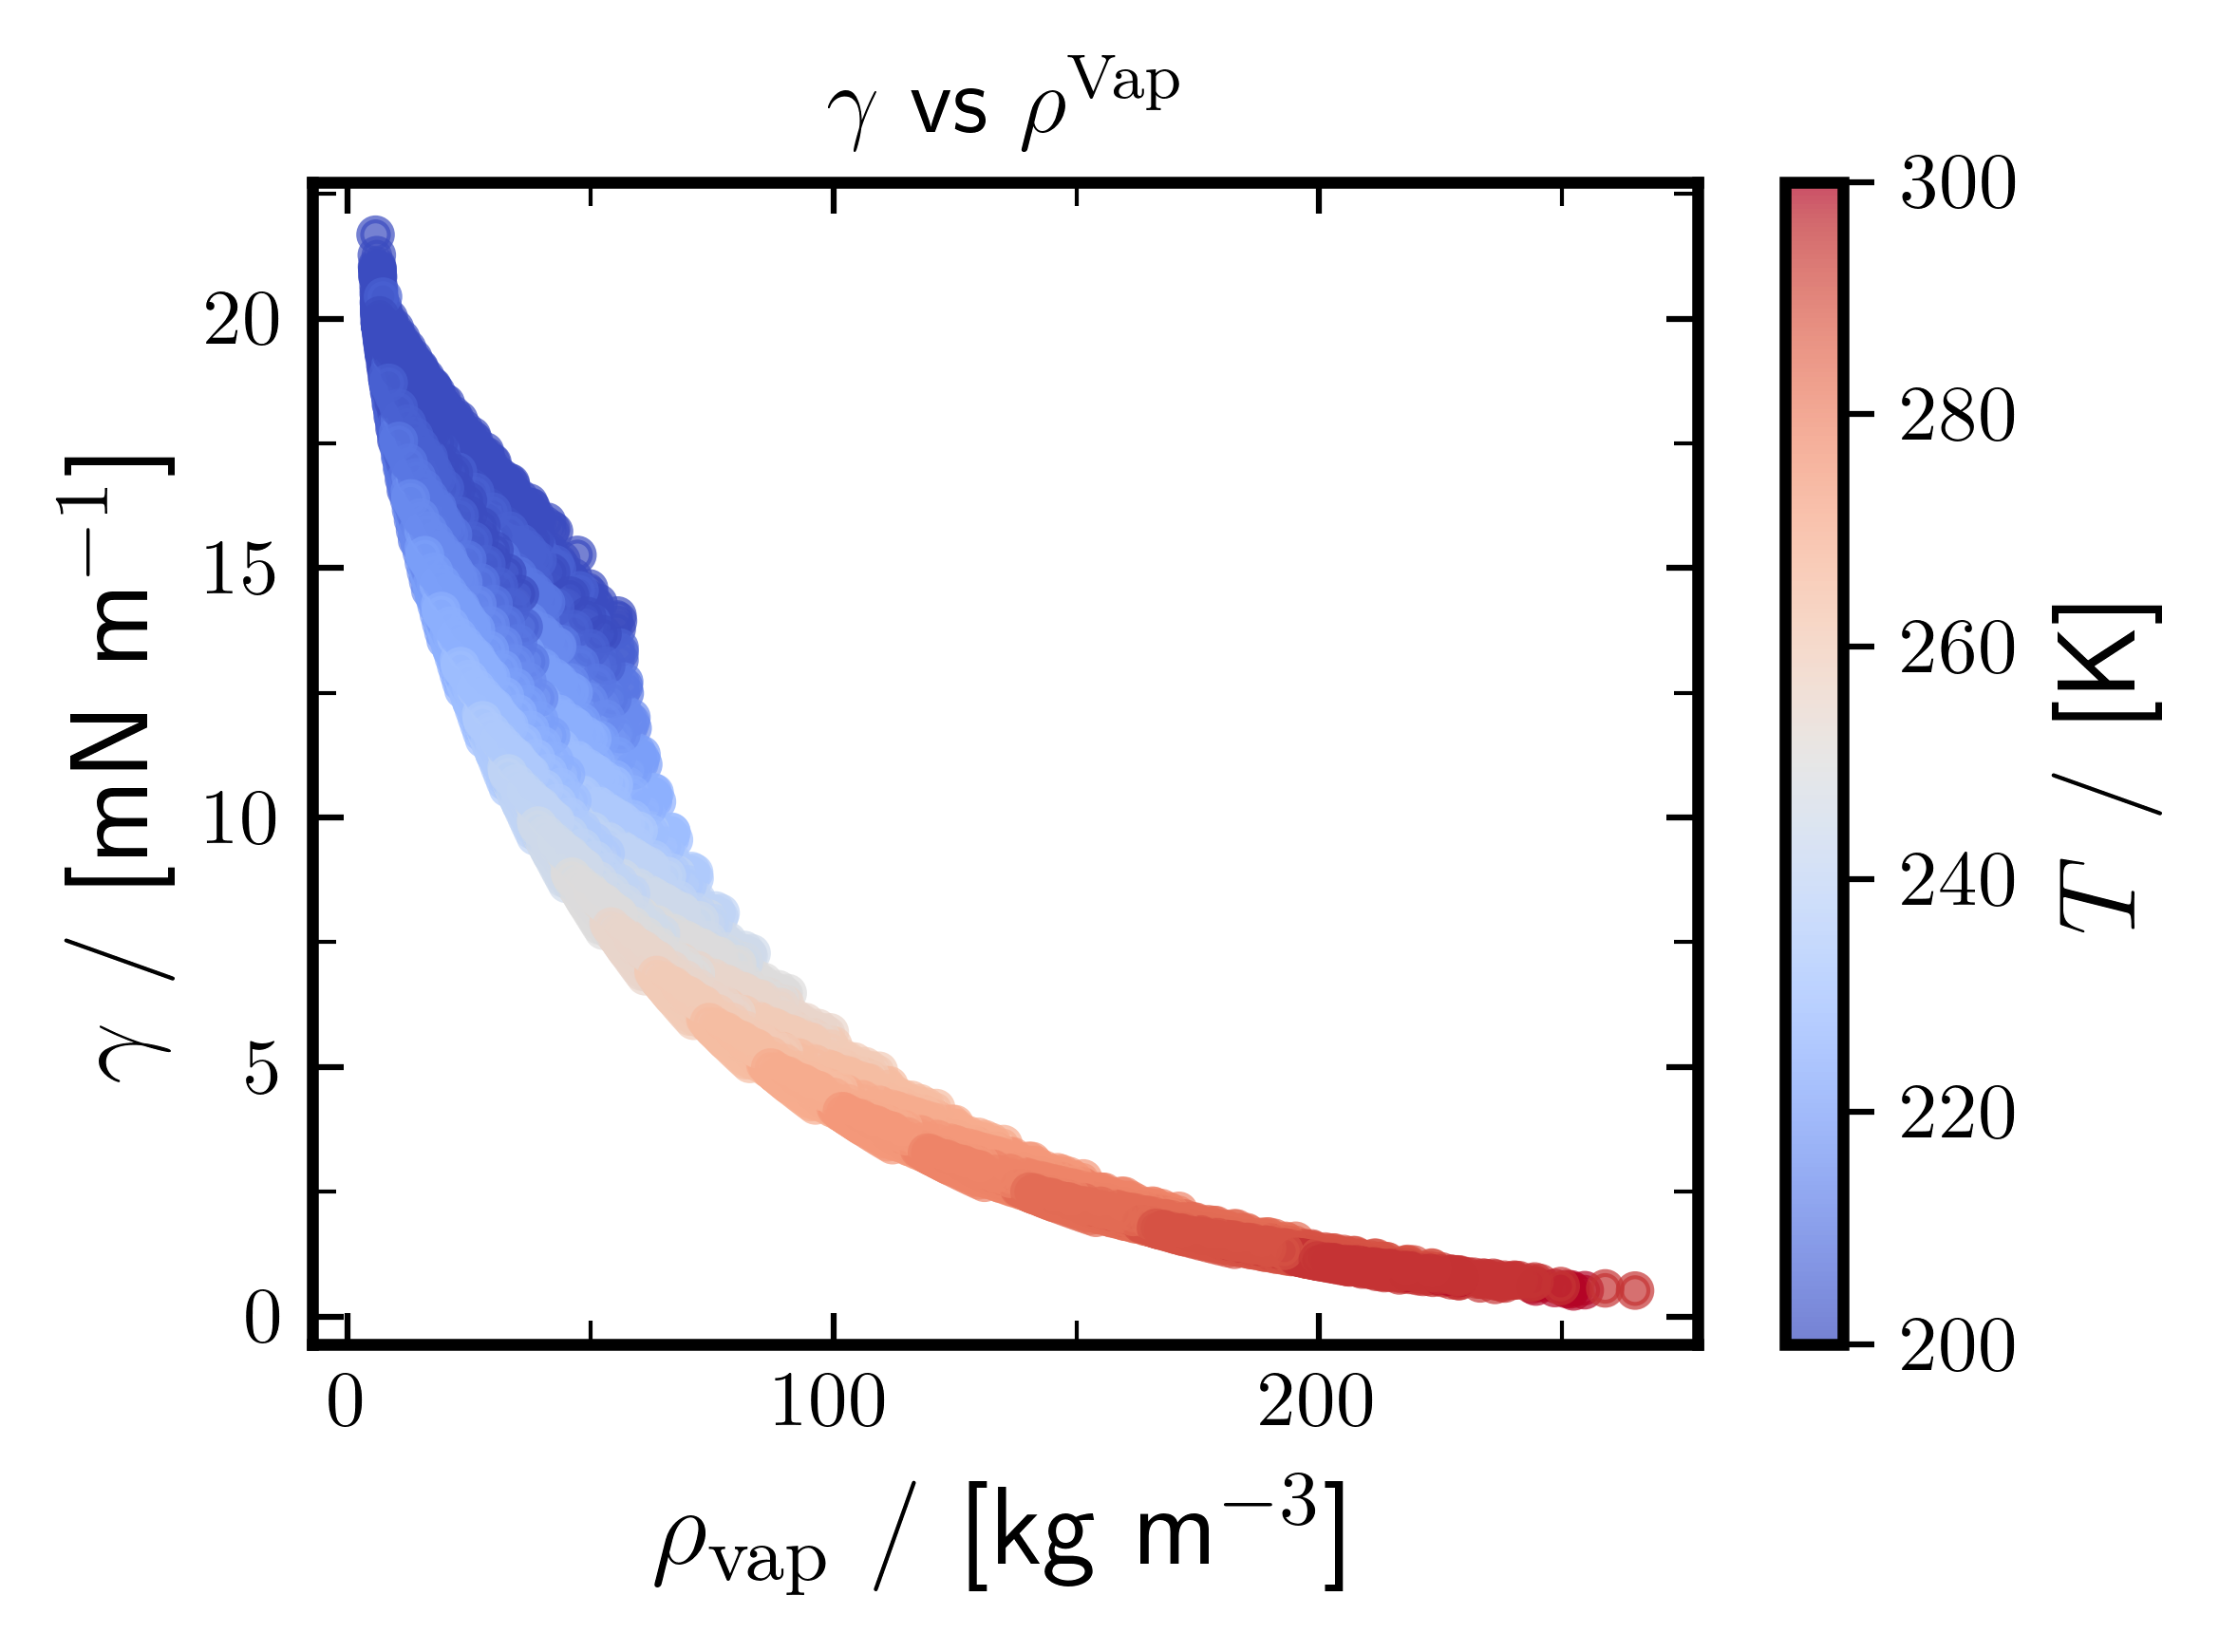

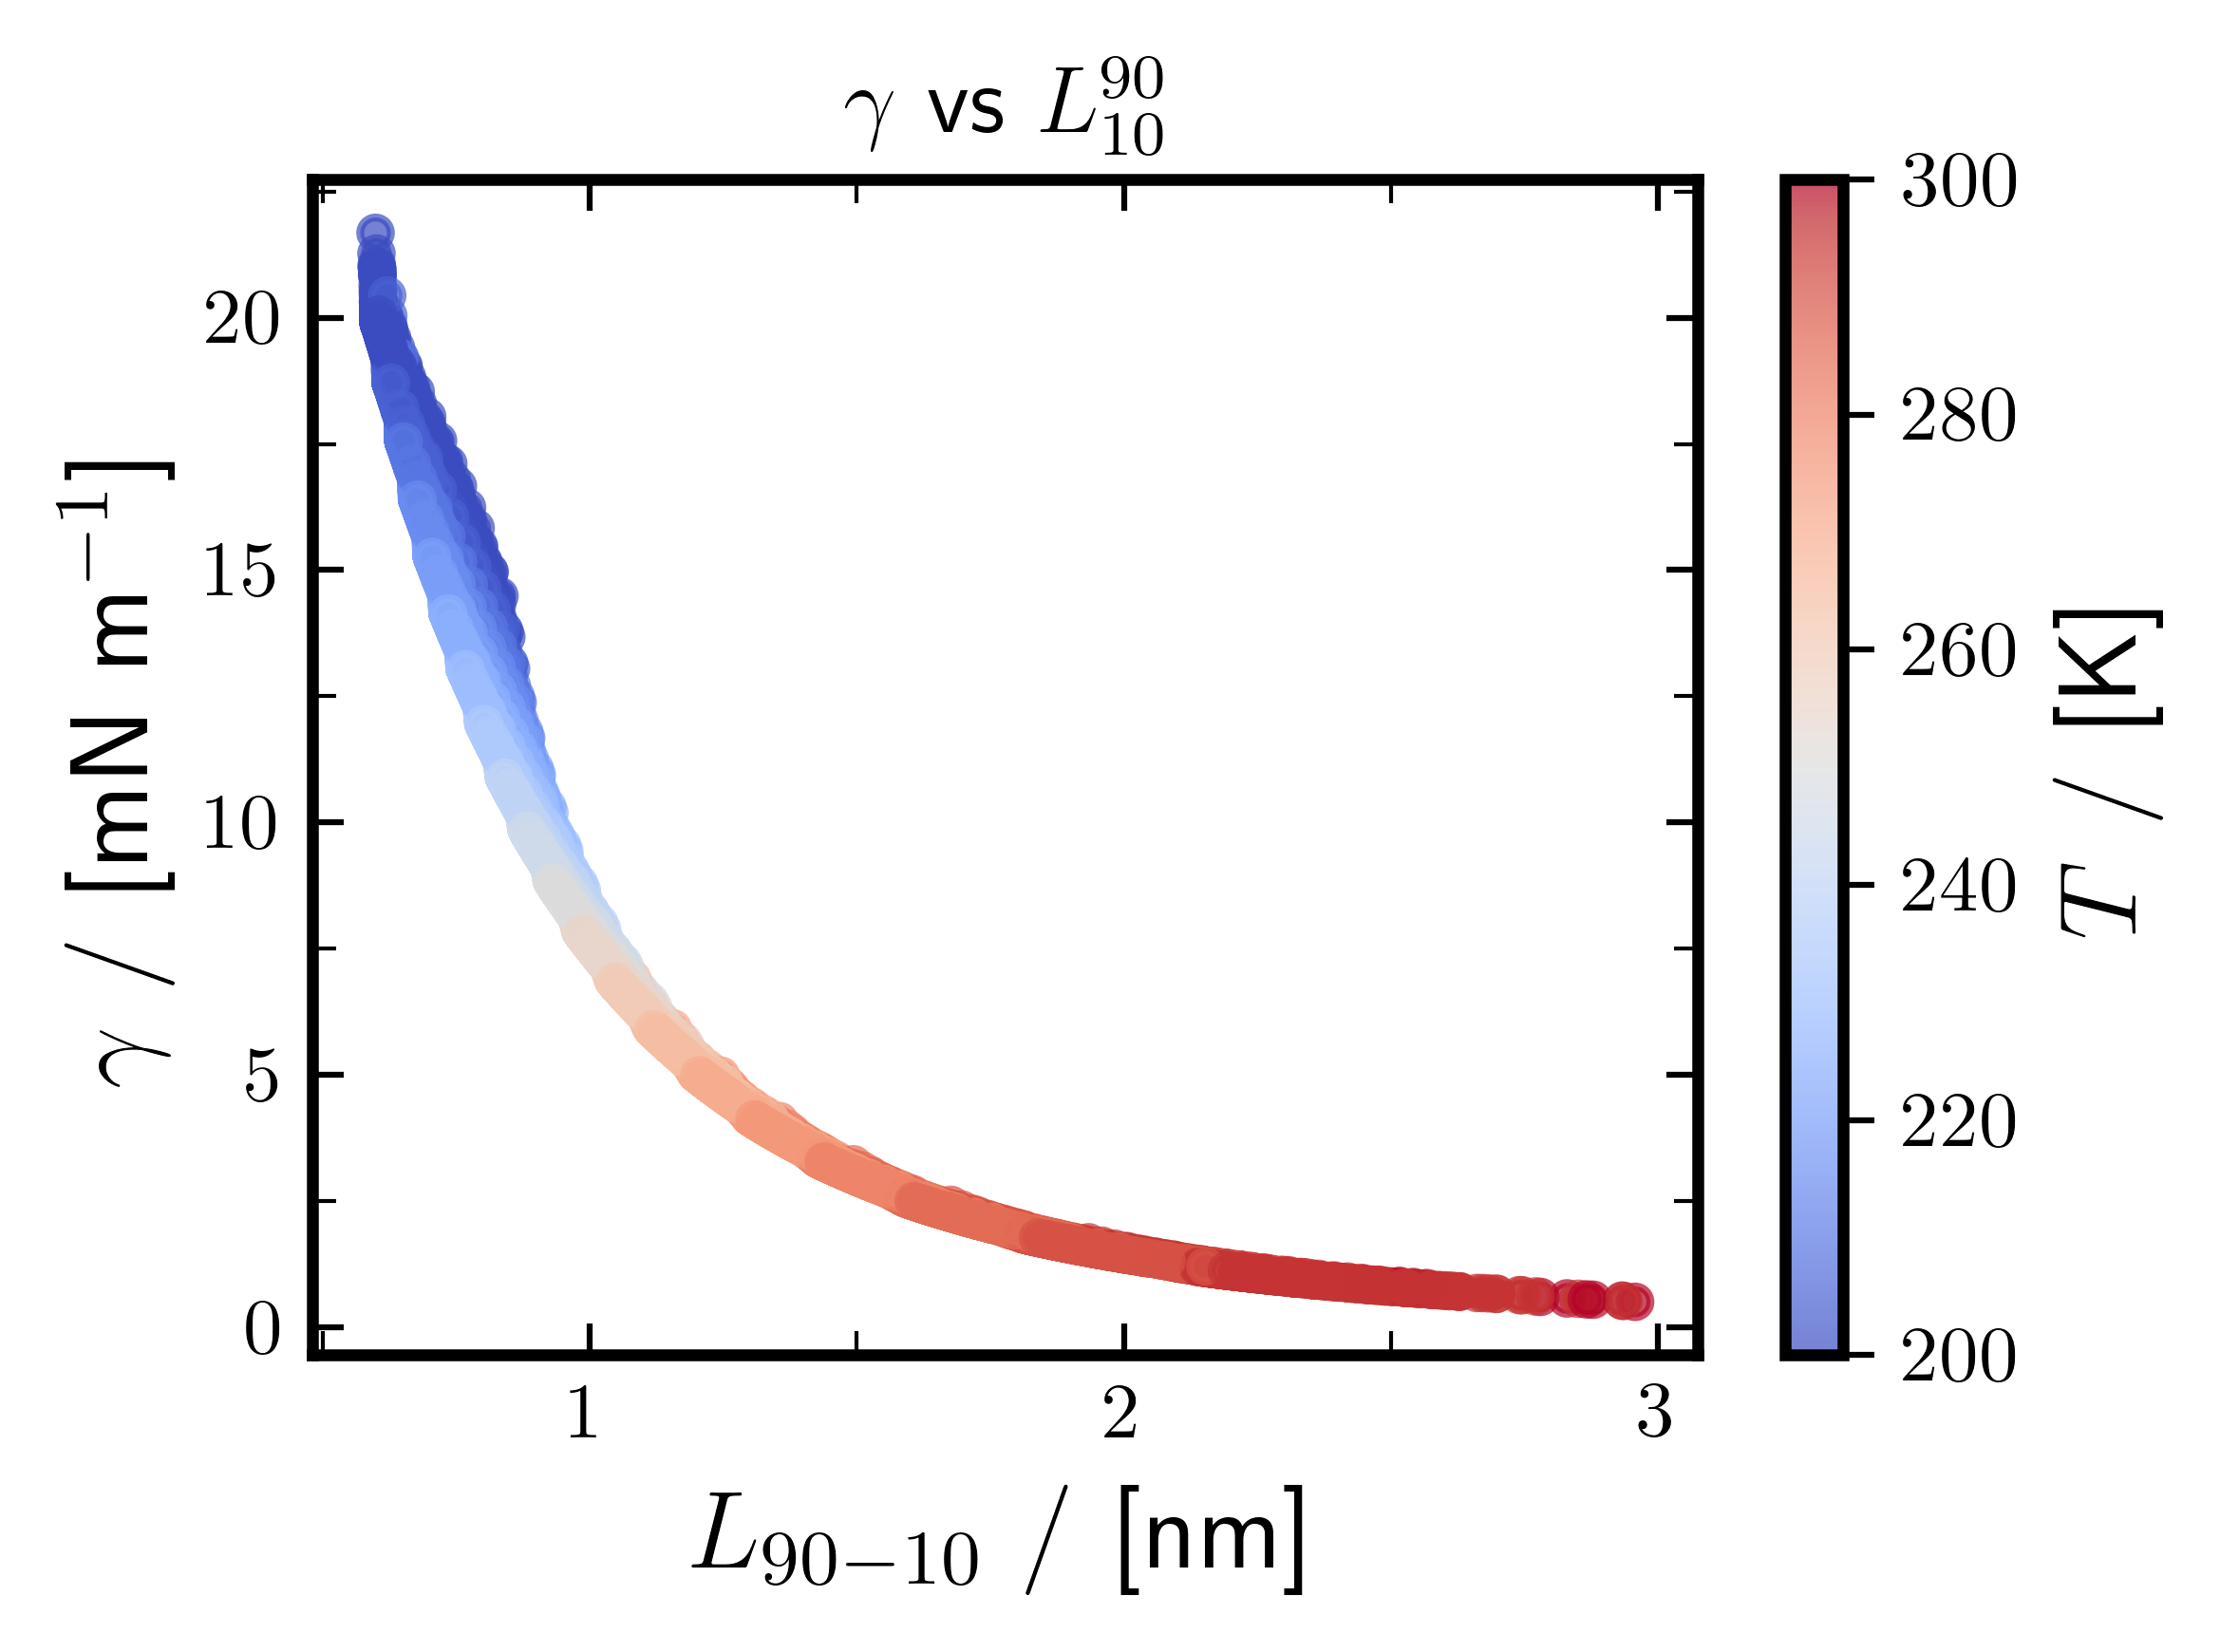

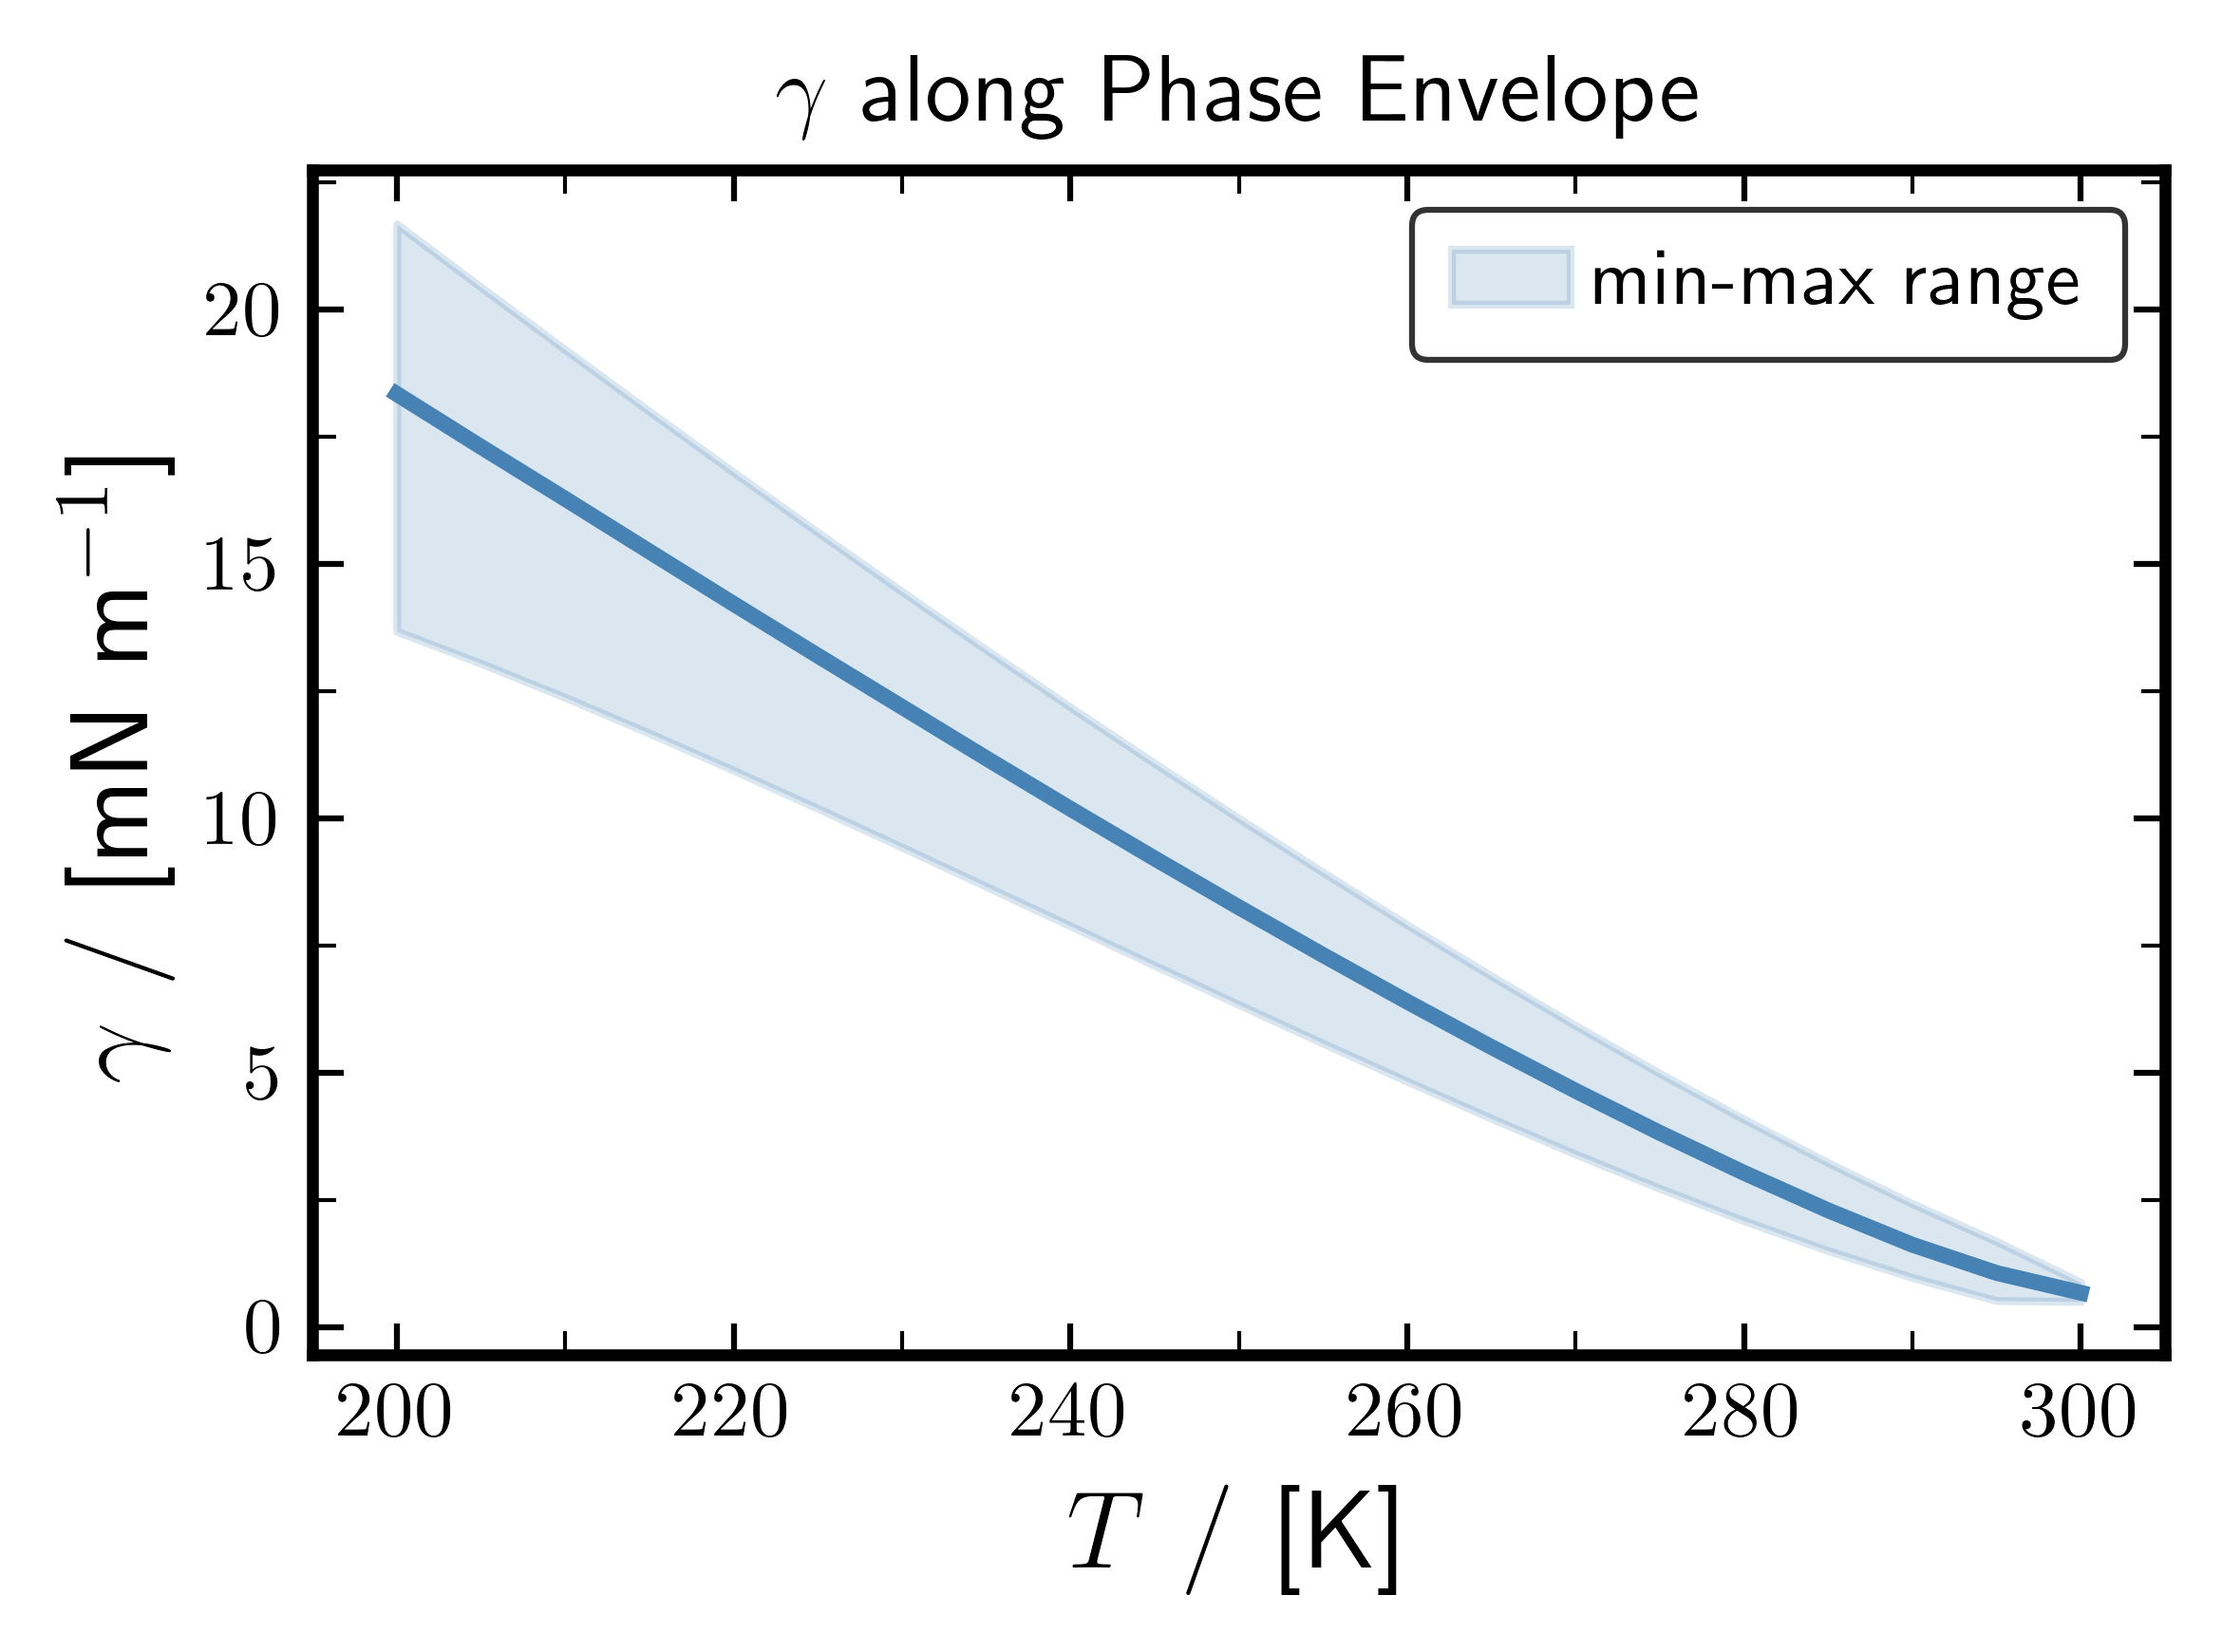

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: title={'center': '$\\gamma$ along Phase Envelope'}, xlabel='$T$ / [K]', ylabel='$\\gamma$ / [mN m$^{-1}$]'>)

In [4]:
prep.plot_target_vs_temperature(save_path="gamma_vs_T")
prep.plot_target_vs_pressure(save_path="gamma_vs_P")
prep.plot_target_distribution(save_path="gamma_distribution")
prep.plot_target_vs_liquid_density(save_path="gamma_vs_rhoL")
prep.plot_target_vs_vapor_density(save_path="gamma_vs_rhoV")
prep.plot_target_vs_interfacial_thickness(save_path="gamma_vs_thickness")
prep.plot_target_phase_envelope(save_path="gamma_phase_envelope")